[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   

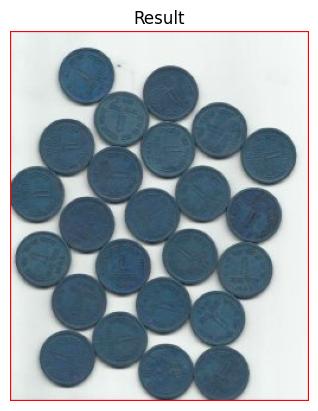

In [ ]:
import cv2
import numpy as np
import heapq
import matplotlib.pyplot as plt

class WSNode:
    def __init__(self, priority, mask_ofs, img_ofs):
        self.priority = priority  # 優先度（色情報の差）
        self.mask_ofs = mask_ofs  # マスクのインデックス
        self.img_ofs = img_ofs    # 画像のインデックス
    def __lt__(self, other):
        return self.priority < other.priority

def custom_watershed(src, markers):
    # src: input, markers: 前景マーカー
    h, w = src.shape[:2]
    IN_QUEUE = -2
    WSHED = -1

    mask = markers.copy()
    img = src.copy()

    istep = w * 3
    mstep = w

    subs_tab = np.zeros(513, dtype=np.int32)
    # 0-255までは0, それ以降は0から256までの数字が入る
    subs_tab[256:] = np.arange(257)
    # max(a,b), min(a,b)を出力(C++でも処理改造のため。pythonならmax(a,b)でもよい)
    def ws_max(a, b): return b + subs_tab[a - b + 256]
    def ws_min(a, b): return a - subs_tab[a - b + 256]

    def c_diff(p1, p2):
        db = abs(int(p1[0]) - int(p2[0]))
        dg = abs(int(p1[1]) - int(p2[1]))
        dr = abs(int(p1[2]) - int(p2[2]))
        return max(db, dg, dr)

    q = [[] for _ in range(256)]  # 優先度キュー

    def push(idx, mofs, iofs):
        heapq.heappush(q[idx], WSNode(idx, mofs, iofs))

    for j in range(w):
        mask[0, j] = WSHED
        mask[h - 1, j] = WSHED
    for i in range(1, h - 1):
        mask[i, 0] = mask[i, w - 1] = WSHED
        for j in range(1, w - 1):
            if mask[i, j] < 0:
                mask[i, j] = 0
            if mask[i, j] == 0 and any(mask[i + di, j + dj] > 0 for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]):
                idx = 256
                center = img[i, j]
                for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    ni, nj = i + di, j + dj
                    if mask[ni, nj] > 0:
                        diff = c_diff(center, img[ni, nj])
                        idx = ws_min(idx, diff)
                mask[i, j] = IN_QUEUE
                push(idx, i * mstep + j, i * istep + j * 3)

    active_queue = next((i for i in range(256) if q[i]), None)
    if active_queue is None:
        return mask
    count = 0
    while True:
        while not q[active_queue]:
            active_queue += 1
            if active_queue >= 256:
                return mask

        node = heapq.heappop(q[active_queue])
        i = node.mask_ofs // mstep
        j = node.mask_ofs % mstep
        m = mask[i, j]
        ptr = img[i, j]
        lab = 0
        for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ni, nj = i + di, j + dj
            t = mask[ni, nj]
            if t > 0:
                if lab == 0:
                    lab = t
                elif t != lab:
                    lab = WSHED
        if lab == 0:
            continue
        mask[i, j] = lab
        if lab == WSHED:
            continue
        for di, dj, d_offset in [(-1, 0, -istep), (1, 0, istep), (0, -1, -3), (0, 1, 3)]:
            ni, nj = i + di, j + dj
            if 0 <= ni < h and 0 <= nj < w and mask[ni, nj] == 0:
                diff = c_diff(ptr, img[ni, nj])
                push(diff, ni * mstep + nj, ni * istep + nj * 3)
                mask[ni, nj] = IN_QUEUE
    return mask

src = cv2.imread(r"Image\water_coins.jpg")
gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
ret, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 距離変換 → ラベリング
dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist, 0.7 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
ret, markers = cv2.connectedComponents(sure_fg)
markers += 1
# 不明領域
kernel = np.ones((3, 3), np.uint8)
sure_bg = cv2.dilate(binary, kernel, iterations=3)
unknown = cv2.subtract(sure_bg, sure_fg)
markers[unknown == 255] = 0

# 実装版Watershed
result = custom_watershed(src, markers)
src[result == -1] = [255, 0, 0]  # 境界を赤で描画
"""
cv2.imshow("Result", src)
cv2.waitKey(0)
cv2.destroyAllWindows()
"""

plt.imshow(src)
plt.title("Result")
plt.axis("off")
plt.show()

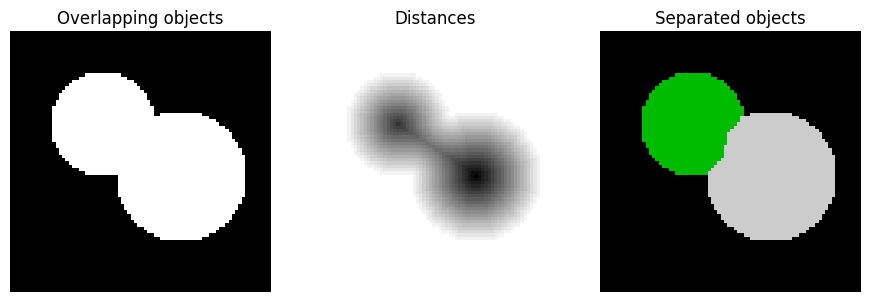

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

from skimage.segmentation import watershed
from skimage.feature import peak_local_max


# Generate an initial image with two overlapping circles
x, y = np.indices((80, 80))
x1, y1, x2, y2 = 28, 28, 44, 52
r1, r2 = 16, 20
mask_circle1 = (x - x1) ** 2 + (y - y1) ** 2 < r1**2
mask_circle2 = (x - x2) ** 2 + (y - y2) ** 2 < r2**2
image = np.logical_or(mask_circle1, mask_circle2)

# Now we want to separate the two objects in image
# Generate the markers as local maxima of the distance to the background
distance = ndi.distance_transform_edt(image)
coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=image)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=image)

fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Overlapping objects')
ax[1].imshow(-distance, cmap=plt.cm.gray)
ax[1].set_title('Distances')
ax[2].imshow(labels, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Separated objects')

for a in ax:
    a.set_axis_off()

fig.tight_layout()
plt.show()